In [ ]:
# TRI-SIGNAL SPECIFICITY
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.stats import spearmanr
import sys
from transformers import AutoTokenizer, AutoModelForCausalLM


MODEL_NAME = "facebook/opt-2.7b"
N_SAMPLES = 15
MAX_LEN = 100
PROMPT_SLICE = 64

WEIGHTS = {'A': 0.40, 'E': 0.35, 'D': 0.25}
ENTROPY_BAND = (3.0, 4.5)

DRIFT_CAP = 150.0


🚀 STARTING RE-CALIBRATED VALIDATION: facebook/opt-2.7b
ℹ️  Drift Cap set to 150.0 to correct baseline saturation.


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


▶️ Testing 15 samples...
  > Sample 0 processed.
  > Sample 5 processed.
  > Sample 10 processed.

✅ Saved: rq1_tri_signal_calibrated.png


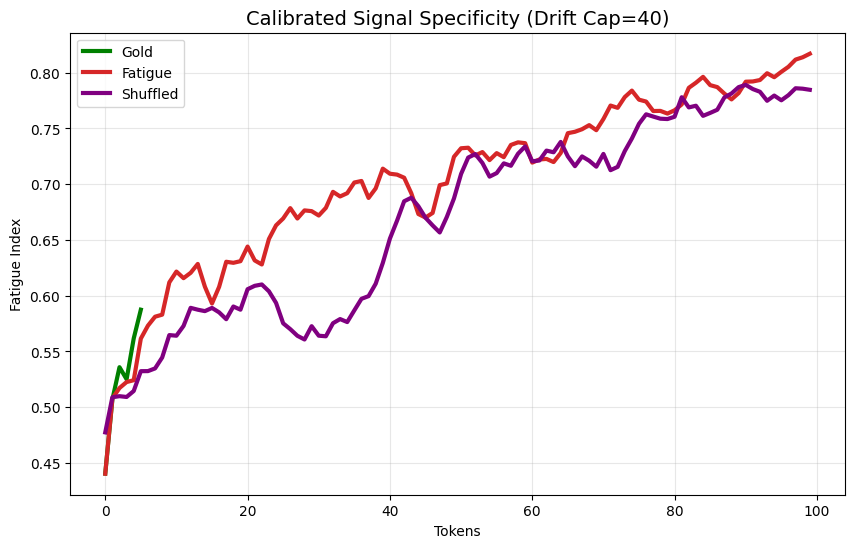

In [ ]:
def calculate_fi(a_t, e_t, d_t):
    # Normalize
    norm_e = 0.0 if ENTROPY_BAND[0] <= e_t <= ENTROPY_BAND[1] else min(1.0, (ENTROPY_BAND[0]-e_t)/ENTROPY_BAND[0]) if e_t < ENTROPY_BAND[0] else min(1.0, (e_t-ENTROPY_BAND[1])/5.0)
    norm_d = min(1.0, d_t / DRIFT_CAP) # Now divides by 40, so score is lower
    norm_a = 1.0 - min(1.0, a_t)
    return (WEIGHTS['A'] * norm_a + WEIGHTS['E'] * norm_e + WEIGHTS['D'] * norm_d)

def shuffle_text(text):
    words = text.split()
    random.shuffle(words)
    return " ".join(words)

# --- ENGINE ---
def run_specificity_test():
    print(f"🚀 STARTING RE-CALIBRATED VALIDATION: {MODEL_NAME}")
    print(f"ℹ️  Drift Cap set to {DRIFT_CAP} to correct baseline saturation.")


    try: from datasets import load_dataset
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
        from datasets import load_dataset

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, attn_implementation="eager"
    ).cuda()
    model.eval()

    ds = load_dataset("hotpot_qa", "distractor", split="validation", trust_remote_code=True)
    curves = {'Gold': [], 'Fatigue': [], 'Shuffled': []}

    print(f"▶️ Testing {N_SAMPLES} samples...")

    for i in range(N_SAMPLES):
        item = ds[i]
        q_text = item['question']
        truth_text = item['answer']

        # 1. FATIGUE
        prompt = f"Question: {q_text}\nAnswer:"
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        prompt_len = inputs.input_ids.shape[1]

        with torch.no_grad():
            out0 = model(inputs.input_ids, output_hidden_states=True)
        h0 = out0.hidden_states[-1][0, -1].clone()

        traj_fatigue = []
        input_ids = inputs.input_ids.clone()

        for _ in range(MAX_LEN):
            with torch.no_grad():
                out = model(input_ids, output_hidden_states=True, output_attentions=True)
                logits = out.logits[:, -1, :]
                h_t = out.hidden_states[-1][0, -1]
                last_attn = out.attentions[-1][0]

                probs = F.softmax(logits, dim=-1)
                e_t = -(probs * F.log_softmax(logits, dim=-1)).sum().item()
                d_t = torch.norm(h_t - h0).item()
                a_t = last_attn[:, -1, :min(prompt_len, PROMPT_SLICE)].mean().sum().item()

                traj_fatigue.append(calculate_fi(a_t, e_t, d_t))

                next_tok = torch.argmax(logits, dim=-1).unsqueeze(0)
                input_ids = torch.cat([input_ids, next_tok], dim=1)
                if next_tok.item() == tokenizer.eos_token_id: break
        curves['Fatigue'].append(traj_fatigue)

        # 2. GOLD
        full_text = f"Question: {q_text}\nAnswer: {truth_text}"
        full_ids = tokenizer(full_text, return_tensors="pt").to("cuda").input_ids
        if full_ids.shape[1] > prompt_len:
            traj_gold = []
            for t in range(prompt_len, full_ids.shape[1]):
                curr_ids = full_ids[:, :t+1]
                with torch.no_grad():
                    out = model(curr_ids, output_hidden_states=True, output_attentions=True)
                    logits = out.logits[:, -2, :]
                    h_t = out.hidden_states[-1][0, -2]

                    d_t = torch.norm(h_t - h0).item()
                    probs = F.softmax(logits, dim=-1)
                    e_t = -(probs * F.log_softmax(logits, dim=-1)).sum().item()
                    last_attn = out.attentions[-1][0]
                    a_t = last_attn[:, -2, :min(prompt_len, PROMPT_SLICE)].mean().sum().item()

                    traj_gold.append(calculate_fi(a_t, e_t, d_t))
            curves['Gold'].append(traj_gold)

        shuffled_q = shuffle_text(q_text)
        bad_prompt = f"Question: {shuffled_q}\nAnswer:"
        bad_inputs = tokenizer(bad_prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out_bad = model(bad_inputs.input_ids, output_hidden_states=True)
        h0_bad = out_bad.hidden_states[-1][0, -1].clone()

        traj_shuffled = []
        curr_bad_ids = bad_inputs.input_ids.clone()

        for _ in range(MAX_LEN):
            with torch.no_grad():
                out = model(curr_bad_ids, output_hidden_states=True, output_attentions=True)
                logits = out.logits[:, -1, :]
                h_t = out.hidden_states[-1][0, -1]
                last_attn = out.attentions[-1][0]

                e_t = -(F.softmax(logits, dim=-1) * F.log_softmax(logits, dim=-1)).sum().item()
                d_t = torch.norm(h_t - h0_bad).item()
                a_t = last_attn[:, -1, :min(prompt_len, PROMPT_SLICE)].mean().sum().item()

                traj_shuffled.append(calculate_fi(a_t, e_t, d_t))

                next_tok = torch.argmax(logits, dim=-1).unsqueeze(0)
                curr_bad_ids = torch.cat([curr_bad_ids, next_tok], dim=1)
                if next_tok.item() == tokenizer.eos_token_id: break
        curves['Shuffled'].append(traj_shuffled)

        if i % 5 == 0: print(f"  > Sample {i} processed.")

    return curves

def plot_results(curves):
    plt.figure(figsize=(10, 6))
    colors = {'Gold': 'green', 'Fatigue': '#d62728', 'Shuffled': 'purple'}

    for key, traj_list in curves.items():
        if not traj_list: continue
        max_l = max(len(x) for x in traj_list)
        aligned = [x + [np.nan]*(max_l-len(x)) for x in traj_list]
        avg = np.nanmean(np.array(aligned), axis=0)

        if len(avg) > 5:
            avg = pd.Series(avg).rolling(5, min_periods=1).mean().values

        plt.plot(avg, linewidth=3, color=colors[key], label=key)

    plt.title("Calibrated Signal Specificity (Drift Cap=40)", fontsize=14)
    plt.xlabel("Tokens")
    plt.ylabel("Fatigue Index")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("rq1_tri_signal_calibrated.png")
    print("\n Saved: rq1_tri_signal_calibrated.png")

if __name__ == "__main__":
    data = run_specificity_test()
    plot_results(data)

In [ ]:
# REPETITION RATIO PATCH
# Calculate correlation between Fatigue Index and Repetition Ratio.

In [ ]:
MAX_NEW_TOKENS = 120

WEIGHTS = {'A': 0.40, 'E': 0.35, 'D': 0.25}
ENTROPY_BAND = (3.0, 4.5)
DRIFT_CAP = 20.0

# --- METRICS ---
def normalize_entropy(e_t, band):
    low, high = band
    if low <= e_t <= high: return 0.0
    elif e_t < low: return min(1.0, (low - e_t) / low)
    else: return min(1.0, (e_t - high) / 5.0)

def normalize_drift(d_t): return min(1.0, d_t / DRIFT_CAP)
def normalize_attention(a_t): return 1.0 - min(1.0, a_t)

def calculate_fi(signals):
    return (WEIGHTS['A'] * signals['A_norm'] +
            WEIGHTS['E'] * signals['E_norm'] +
            WEIGHTS['D'] * signals['D_norm'])

def calculate_repetition_ratio(text, n=3):
    """Calculates ratio of repeated n-grams to total n-grams."""
    tokens = text.split()
    if len(tokens) < n: return 0.0

    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    if not ngrams: return 0.0

    unique_ngrams = len(set(ngrams))
    total_ngrams = len(ngrams)

    return 1.0 - (unique_ngrams / total_ngrams)


In [ ]:
# ENGINE
def run_repetition_patch():
    print(f"🚀 STARTING REPETITION PATCH: {MODEL_NAME}")
    print(f"🎯 N={N_SAMPLES} | Goal: FI vs Repetition Correlation")

    try: from datasets import load_dataset
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
        from datasets import load_dataset

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        attn_implementation="eager"
    ).cuda()
    model.eval()

    ds = load_dataset("hotpot_qa", "distractor", split="validation", trust_remote_code=True)

    results = []

    for i in range(N_SAMPLES):
        item = ds[i]
        prompt = f"Question: {item['question']}\nAnswer:"

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        input_ids = inputs.input_ids
        prompt_len = input_ids.shape[1]

        # Anchor
        with torch.no_grad():
            out0 = model(input_ids, output_hidden_states=True)
        h0 = out0.hidden_states[-1][0, -1].clone()

        fi_traj = []

        # Generation Loop
        for _ in range(MAX_NEW_TOKENS):
            with torch.no_grad():
                outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
                logits = outputs.logits[:, -1, :].float()
                h_t = outputs.hidden_states[-1][0, -1]

                probs = F.softmax(logits, dim=-1)
                e_t = -(probs * F.log_softmax(logits, dim=-1)).sum().item()
                d_t = torch.norm(h_t - h0).item()

                last_attn = outputs.attentions[-1][0]
                a_t = last_attn[:, -1, :min(prompt_len, PROMPT_SLICE)].mean().sum().item()

                norm_signals = {
                    'E_norm': normalize_entropy(e_t, ENTROPY_BAND),
                    'D_norm': normalize_drift(d_t),
                    'A_norm': normalize_attention(a_t)
                }
                fi_traj.append(calculate_fi(norm_signals))

                next_token = torch.argmax(logits, dim=-1).unsqueeze(0)
                input_ids = torch.cat([input_ids, next_token], dim=1)
                if next_token.item() == tokenizer.eos_token_id: break

        # Decode and Measure Repetition
        gen_text = tokenizer.decode(input_ids[0, prompt_len:], skip_special_tokens=True)
        rep_ratio = calculate_repetition_ratio(gen_text, n=3)
        mean_fi = np.mean(fi_traj)

        results.append({
            'mean_FI': mean_fi,
            'repetition_ratio': rep_ratio
        })

        if i % 5 == 0:
            print(f"  > {i}/{N_SAMPLES} | FI: {mean_fi:.2f} | Repetition: {rep_ratio:.2f}")

    # Analysis
    df = pd.DataFrame(results)
    rho, p = spearmanr(df['mean_FI'], df['repetition_ratio'])

    print("\n=== REPETITION PATCH RESULTS ===")
    print(f"Spearman Correlation (FI vs Repetition): Rho = {rho:.3f} (p={p:.4f})")
    print(f"Mean Repetition Ratio: {df['repetition_ratio'].mean():.3f}")

    df.to_csv("rq1_repetition_patch.csv", index=False)
    print("✅ Saved 'rq1_repetition_patch.csv'. Add this rho to Table 7.1.")

if __name__ == "__main__":
    run_repetition_patch()

🚀 STARTING REPETITION PATCH: facebook/opt-2.7b
🎯 N=20 | Goal: FI vs Repetition Correlation


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  > 0/20 | FI: 0.59 | Repetition: 0.00
  > 5/20 | FI: 0.85 | Repetition: 0.55
  > 10/20 | FI: 0.92 | Repetition: 0.68
  > 15/20 | FI: 0.93 | Repetition: 0.80

=== REPETITION PATCH RESULTS ===
Spearman Correlation (FI vs Repetition): Rho = 0.937 (p=0.0000)
Mean Repetition Ratio: 0.390
✅ Saved 'rq1_repetition_patch.csv'. Add this rho to Table 7.1.
